<a href="https://colab.research.google.com/github/vis-hal-git/Blood-Cancer-Prediction/blob/main/Model_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mehradaria/leukemia")

100%|██████████| 110M/110M [00:00<00:00, 193MB/s] 

Extracting files...


In [ ]:
import os

base_dir = os.path.join(path, "Segmented")  # Recommended

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
import shutil
from sklearn.model_selection import train_test_split

base_dir = os.path.join(path, "Segmented")   # Recommended

new_base = "/content/leukemia_split"
os.makedirs(new_base, exist_ok=True)

for category in os.listdir(base_dir):
    category_path = os.path.join(base_dir, category)
    images = os.listdir(category_path)

    train, temp = train_test_split(images, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)

    for split_name, split_data in zip(["train","val","test"], [train,val,test]):
        split_folder = os.path.join(new_base, split_name, category)
        os.makedirs(split_folder, exist_ok=True)

        for img in split_data:
            shutil.copy(
                os.path.join(category_path, img),
                os.path.join(split_folder, img)
            )

print("Dataset Split Completed")

Dataset Split Completed


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_dir = os.path.join(new_base, "train")
val_dir = os.path.join(new_base, "val")
test_dir = os.path.join(new_base, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 2277 images belonging to 4 classes.
Found 489 images belonging to 4 classes.
Found 490 images belonging to 4 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.6171875), 1: np.float64(0.8261973875181422), 2: np.float64(0.8445845697329377), 3: np.float64(1.012900355871886)}


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.2416 - loss: 1.5618

72/72 ━━━━━━━━━━━━━━━━━━━━ 101s 993ms/step - accuracy: 0.2418 - loss: 1.5612 - val_accuracy: 0.1554 - val_loss: 1.3937 - learning_rate: 1.0000e-04
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.2660 - loss: 1.4601

72/72 ━━━━━━━━━━━━━━━━━━━━ 78s 368ms/step - accuracy: 0.2663 - loss: 1.4598 - val_accuracy: 0.1554 - val_loss: 1.3884 - learning_rate: 1.0000e-04
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.3030 - loss: 1.4229

72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 373ms/step - accuracy: 0.3031 - loss: 1.4230 - val_accuracy: 0.1636 - val_loss: 1.3825 - learning_rate: 1.0000e-04
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.3480 - loss: 1.3771

...

72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 375ms/step - accuracy: 0.4548 - loss: 1.2143 - val_accuracy: 0.4663 - val_loss: 1.1756 - learning_rate: 1.0000e-04
Epoch 16/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.4592 - loss: 1.2227

72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 380ms/step - accuracy: 0.4595 - loss: 1.2226 - val_accuracy: 0.4867 - val_loss: 1.1550 - learning_rate: 1.0000e-04
Epoch 17/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.4937 - loss: 1.1902

72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 380ms/step - accuracy: 0.4938 - loss: 1.1902 - val_accuracy: 0.4867 - val_loss: 1.1466 - learning_rate: 1.0000e-04
Epoch 18/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.4841 - loss: 1.2007

72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 371ms/step - accuracy: 0.4841 - loss: 1.2007 - val_accuracy: 0.4847 - val_loss: 1.1408 - learning_rate: 1.0000e-04
Epoch 19/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 364ms/step - accuracy: 0.5152 - loss: 1.2100 - val_accuracy: 0.4785 - val_loss: 1.1469 - learning_rate: 1.0000e-04
Epoch 20/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.4980 - loss: 1.1649

72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 368ms/step - accuracy: 0.4979 - loss: 1.1651 - val_accuracy: 0.5072 - val_loss: 1.1094 - learning_rate: 1.0000e-04


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 79s 706ms/step - accuracy: 0.2655 - loss: 2.0202 - val_accuracy: 0.2474 - val_loss: 1.9262
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 396ms/step - accuracy: 0.3132 - loss: 1.7497 - val_accuracy: 0.2474 - val_loss: 2.5348
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 365ms/step - accuracy: 0.3345 - loss: 1.6146 - val_accuracy: 0.2474 - val_loss: 2.2691
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 369ms/step - accuracy: 0.3713 - loss: 1.5490 - val_accuracy: 0.2474 - val_loss: 2.1342
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 369ms/step - accuracy: 0.3500 - loss: 1.5901 - val_accuracy: 0.2474 - val_loss: 1.7812
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 373ms/step - accuracy: 0.3740 - loss: 1.5547 - val_accuracy: 0.2986 - val_loss: 1.4309
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 374ms/step - accuracy: 0.3813 - loss: 1.4993 - val_accuracy: 0.2454 - val_loss: 1.3336
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 368ms/step - accuracy: 0.3861 - loss: 1.4637 - val_accu

16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 519ms/step
              precision    recall  f1-score   support

           0       0.16      0.99      0.28        76
           1       0.00      0.00      0.00       148
           2       0.97      0.22      0.36       145
           3       0.00      0.00      0.00       121

    accuracy                           0.22       490
   macro avg       0.28      0.30      0.16       490
weighted avg       0.31      0.22      0.15       490



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


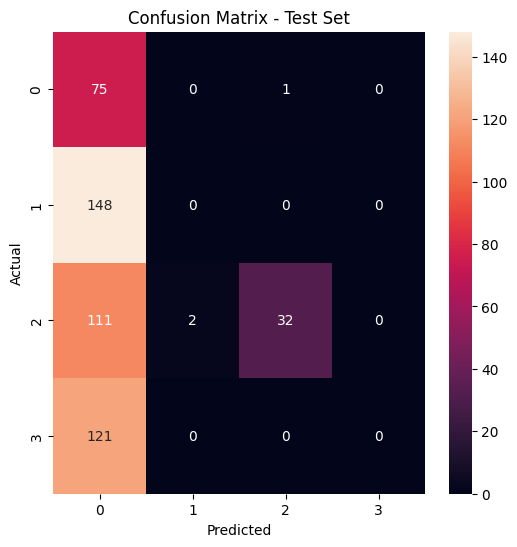

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_gen.reset()
pred = model.predict(test_gen)
y_pred = np.argmax(pred, axis=1)

print(classification_report(test_gen.classes, y_pred))

cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

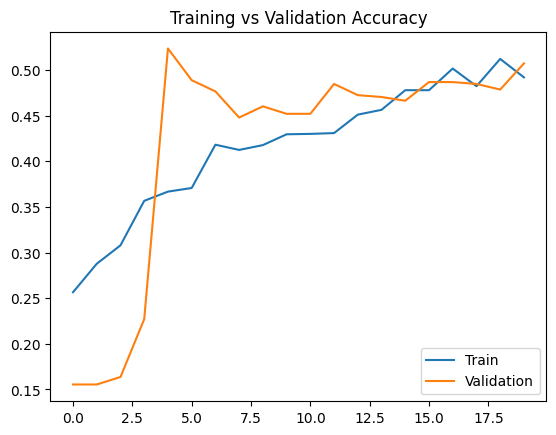

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [ ]:
print("Best Validation Accuracy:", max(history.history['val_accuracy']))

Best Validation Accuracy: 0.523517370223999
